# Implementacão - Multiprocessing

## Detalhes

1. Mutiprocessing utilzia fork() (no Linux). O processo filho nasce como uma cópia exata da memória do pai.

2. Copy-on-Write (fork)
- Ao utilizar *multiprocessing* os dados não são copiados; o filho herda a memória. Assim, o custo de transferência de dados é praticamente zero.
- Multiprocessing utiliza variáveis globais (como A_global) que já estão na memória do filho sem custo de cópia ("Zero-copy" via Copy-on-Write).



## Confirmação de versão do Python em uso

In [1]:
import sys
print(sys.version_info)

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)


In [4]:
import multiprocessing as mp
import psutil
import getpass
import os
import sys
import time
import numpy as np
import pandas as pd
from datetime import datetime

# --------------------------------------
# CONFIGURATION

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

MATRIX_SIZE = 2000  # size of NxN matrices

#CPU_SETS = {
#    "p-cores 1 thread": [0, 2, 4, 6, 8, 10, 12, 14], # p-cores (8 cores, 1 thread per core)
#    "p-cores 2 threads": [0, 1, 2, 3, 4, 5, 6, 7], # p-cores (4 cores, 2 threads per core)
#    "p-cores & e-cores 50-50": [0, 2, 4, 6, 16, 17, 18, 19], # p-cores e e-cores (4 cores p-core, 4 cores e-core)
#    "e-cores": [16, 17, 18, 19, 20, 21, 22, 23] # e-cores (8 cores, 1 thread per core)
#}

CPU_SETS = {
    "1-T": [0],
    "2-T": [0, 2],
    "2-T-HP": [0, 1],
    "4-T": [0, 2, 4, 6],
    "4-T-HP": [0, 1, 2, 3],
    "8-T": [0, 2, 4, 6, 8, 10, 12, 14],
    "8-T-HP": [0, 1, 2, 3, 4, 5,6,7],    
}

NUM_RUNS = 2   # runs per CPU set
GOVERNOR = "performance"
IDLE_TIME = 1  # segundos entre execuções

# Variáveis globais (matrizes) para serem herdadas pelos workers
A_global = None
B_global = None

# --------------------------------------
# Safety check
def safety_check(cpu_ids):
    if MATRIX_SIZE % len(cpu_ids) != 0:
        print(f"Error: MATRIX_SIZE ({MATRIX_SIZE}) is not divisible by number of workers ({len(cpu_ids)}).")
        sys.exit(1)

# --------------------------------------
# Governor configuration
def set_governor(governor: str):
    """
    Altera o CPU governor de todos os núcleos para o valor especificado.

    Parâmetros:
        governor (str): nome do governor (ex.: "performance", "powersave", "schedutil").
    """
    password = getpass.getpass("Sudo password: ")

    # Interpolamos o valor do parâmetro governor dirTempetamente no comando bash
    bash_command = f"""
    for cpu_file in $(ls -v /sys/devices/system/cpu/cpu*/cpufreq/scaling_governor); do
        cpu_name=$(basename $(dirname $(dirname $cpu_file)))
        
        echo "{governor}" | sudo tee $cpu_file > /dev/null
        
        current_gov=$(cat $cpu_file)
        echo "$cpu_name: $current_gov"
    done
    """

    # Usa sudo -S para aceitar senha via stdin
    command = f'echo "{password}" | sudo -S bash -c \'{bash_command}\''
    os.system(command)    
        
# --------------------------------------
# Governor detection
def get_governor(cpu_id):
    path = f"/sys/devices/system/cpu/cpu{cpu_id}/cpufreq/scaling_governor"
    try:
        with open(path) as f:
            return f.read().strip()
    except FileNotFoundError:
        return "N/A"

# Worker task: Acessa as matrizes globais
def worker_task_global(args):
    row_index, chunk_size, cpu_ids = args
    worker_id = row_index // chunk_size # Calcula um ID simples para o worker
    
    # Define a afinidade
    p = psutil.Process(os.getpid())
    p.cpu_affinity([cpu_ids[worker_id]])
    
    # Pega o chunk da matriz A global
    start_row = row_index
    end_row = row_index + chunk_size
    A_chunk = A_global[start_row:end_row, :]
    
    # Calcula usando a matriz B global (que foi herdada, não copiada)
    return np.dot(A_chunk, B_global)

# --------------------------------------
# Main execution loop
if __name__ == "__main__":
    
    print("Passo 1: Configurar governor")
    set_governor(GOVERNOR)
    
    results = []  # lista para armazenar resultados      
    
    # Inicializa as matrizes globais
    A_global = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)
    B_global = np.random.rand(MATRIX_SIZE, MATRIX_SIZE).astype(np.float64)
    
    print("Passo 2: Execuções")
    for run in range(1, NUM_RUNS + 1):        
        for label, cores in CPU_SETS.items():
            # Garantir que o workload será dividido igualmente
            safety_check(cores)
            
            # Garantir que o governor está correto
            governor = get_governor(cores[0])

            # Split A into chunks by rows
            chunk_size = MATRIX_SIZE // len(cores)
            
            # Tarefas agora contêm apenas índices, muito leves
            tasks = [(i*chunk_size, chunk_size, cores) for i in range(len(cores))]

            start_time = time.time()
            
            # Criação do pool. Matrizes herdadas por fork()
            with mp.Pool(processes=len(cores)) as pool:
                C_chunks = pool.map(worker_task_global, tasks)
            
            # Combinação de resultados
            C = np.vstack(C_chunks)
            
            end_time = time.time()
            total_time = end_time - start_time
            
            # Validação de resultados
            #C_reference = np.matmul(A_global, B_global)
            #is_match = np.allclose(C, C_reference)
            #validacao_ok = "OK" if is_match else "FAIL"
            #print(f"  -> Validação: {validacao_ok}")
            
            # salva os dados em um dataFrame
            results.append({
                "Run": run,
                "Scenario": label,
                "CPUs_used": cores,
                "Governor": governor,
                "Time_sec": total_time,
                "Result_shape": C.shape
            })
            
            print(f"Run {run} | {label}: {cores} | Governor: {governor} | Time: {total_time}")

            # Idle para estabilizar
            print(f"Aguardando {IDLE_TIME} segundos para estabilização...\n")
            time.sleep(IDLE_TIME)
            
    # cria dataframe com todos os resultados
    df_results = pd.DataFrame(results)
    pd.set_option('display.width', 1000) # Evita quebra de linha do print do df  
    df_reduced = df_results[["Run", "Scenario", "Governor", "Time_sec"]]
    df_sorted = df_reduced.sort_values(by="Scenario", ascending=False)
    print("\nResumo em DataFrame:\n", df_sorted)
    
    # salvar em CSV
    now = datetime.now()
    data_str = now.strftime("%Y%m%d") # formato aaaammdd
    hora_str = now.strftime("%H%M%S") # formato hhmmss
    filename = (
    f"{data_str}_{hora_str}_matrix{MATRIX_SIZE}_"
        f"numruns{NUM_RUNS}_{GOVERNOR}.csv"
    )
    df_results.to_csv(filename, index=False)
    print(f"\nResultados salvos em: {filename}")           
            

Passo 1: Configurar governor
Sudo password: ········


[sudo] senha para jgross: 

cpu0: performance
cpu1: performance
cpu2: performance
cpu3: performance
cpu4: performance
cpu5: performance
cpu6: performance
cpu7: performance
cpu8: performance
cpu9: performance
cpu10: performance
cpu11: performance
cpu12: performance
cpu13: performance
cpu14: performance
cpu15: performance
cpu16: performance
cpu17: performance
cpu18: performance
cpu19: performance
cpu20: performance
cpu21: performance
cpu22: performance
cpu23: performance
cpu24: performance
cpu25: performance
cpu26: performance
cpu27: performance
Passo 2: Execuções
Run 1 | 1-T: [0] | Governor: performance | Time: 3.629058361053467
Aguardando 1 segundos para estabilização...

Run 1 | 2-T: [0, 2] | Governor: performance | Time: 1.6997344493865967
Aguardando 1 segundos para estabilização...

Run 1 | 2-T-HP: [0, 1] | Governor: performance | Time: 2.6116392612457275
Aguardando 1 segundos para estabilização...

Run 1 | 4-T: [0, 2, 4, 6] | Governor: performance | Time: 0.9471662044525146
Aguardando 1 segundos para estabili

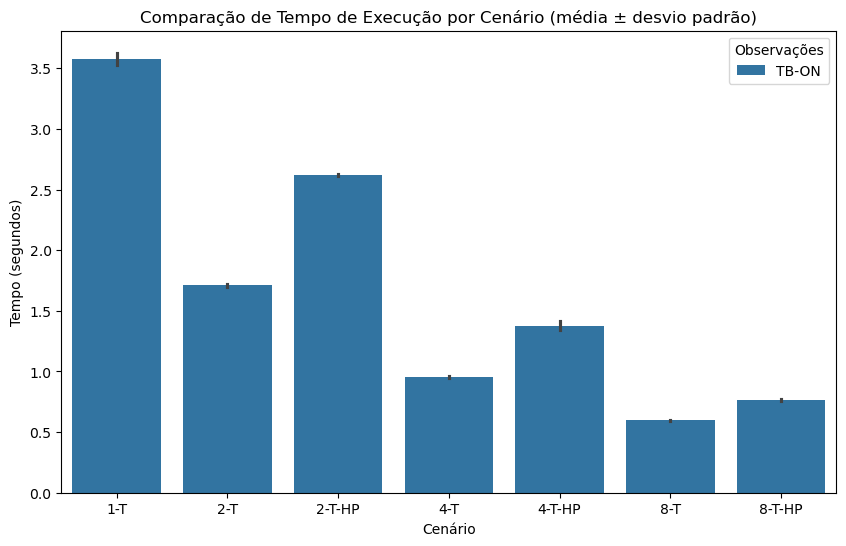

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Supondo que seus arquivos estejam em CSV
df1 = pd.read_csv('20251117_205240_matrix2000_numruns2_performance.csv') # Com Turbo Bost
#df2 = pd.read_csv('20251111_170848_matrix1000_numruns5_performance.csv') 

df1['Dataset'] = 'TB-ON'
#df2['Dataset'] = '-'

#df_combined = pd.concat([df1, df2], ignore_index=True)

plt.figure(figsize=(10,6))
#sns.barplot(x='Scenario', y='Time_sec', hue='Dataset', data=df_combined, ci='sd')
sns.barplot(
    x='Scenario',
    y='Time_sec',
    hue='Dataset',
    data=df1,
    estimator='mean'       # calcula a média automaticamente
    #errorbar='sd'           # mostra desvio padrão
)
plt.title('Comparação de Tempo de Execução por Cenário (média ± desvio padrão)')
plt.ylabel('Tempo (segundos)')
plt.xlabel('Cenário')
plt.legend(title='Observações')

# Salvar como PDF
#plt.savefig('grafico_time_sec.pdf', format='pdf', bbox_inches='tight')

# Salvar como PNG
plt.savefig('grafico_time_sec.png', format='png', dpi=300, bbox_inches='tight')

plt.show()